In [1]:
#定义dropout函数,根据概率丢弃一些X
import torch
from torch import nn
from d2l import torch as d2l
from torchvision import datasets,transforms
from torch.utils.data import DataLoader

def dropout_layer(X,dropout):
    assert dropout>=0 and dropout<=1
    if dropout==1:
        return torch.zeros_like(X)
    if dropout==0:
        return X
    mask=(torch.randn(X.shape)>dropout).float()
    return mask*X/(1-dropout)

In [2]:
#准备数据集
transform = transforms.ToTensor()
train_dataset = datasets.FashionMNIST(
    root="D:/datasets/fashionmnist",
    train=True,
    transform = transform,
    download=True
)
test_dataset = datasets.FashionMNIST(
    root="D:/datasets/fashionmnist",
    train = True,
    transform = transform,
    download = True
)
train_iter=DataLoader(train_dataset,shuffle=True)
test_iter=DataLoader(test_dataset,shuffle=True)

In [3]:
X = torch.arange(16,dtype=torch.float32).reshape(2,8)
print(X)
print(dropout_layer(X,0.))
print(dropout_layer(X,0.5))
print(dropout_layer(X,1.))

tensor([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11., 12., 13., 14., 15.]])
tensor([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11., 12., 13., 14., 15.]])
tensor([[ 0.,  2.,  4.,  0.,  0.,  0.,  0.,  0.],
        [16.,  0., 20.,  0.,  0., 26.,  0.,  0.]])
tensor([[0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.]])


In [4]:
num_inputs,num_outputs,num_hiddens1,num_hiddens2=784,10,256,256
dropout1,dropout2=0.2,0.5

class NET(nn.Module):
    def __init__(self,num_inputs,num_outputs,num_hiddens1,num_hiddens2,is_training = True):
        super().__init__()
        self.num_inputs=num_inputs
        self.lin1=nn.Linear(num_inputs,num_hiddens1)
        self.lin2=nn.Linear(num_hiddens1,num_hiddens2)
        self.lin3=nn.Linear(num_hiddens2,num_outputs)
        self.training=True
        self.relu=nn.ReLU()

    def forward(self,X):
        H1=self.relu(self.lin1(X.reshape((-1,self.num_inputs))))
        if self.training == True:
            H1=dropout_layer(H1,dropout1)
        H2=self.relu(self.lin2(H1))
        if self.training == True:
            H2=dropout_layer(H2,dropout2)
        out=self.lin3(H2)
        return out

In [5]:
net = NET(num_inputs,num_outputs,num_hiddens1,num_hiddens2,is_training=True)

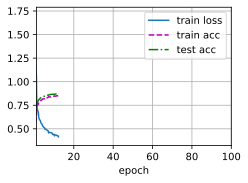

In [ ]:
num_epochs,lr=100,0.001
loss = nn.CrossEntropyLoss()
device = torch.device("cpu")
d2l.train_ch6(net,train_iter,test_iter,num_epochs,lr,device)